# **Bank Telemarketing Case Study** 🏦
<pre>
Description:  We are provided with Bank's Existing Customers Data.

A telemarketing Campaign was Done by the Bank Offering Various Banking Products .eg Term Deposits/FD

As an Analyst we are required to Perform EDA on Telemarketing Campaign Dta and Find Various Insights / Facts From Data.

Facts/Insights Shared by us are to be used by the Management to increase Profits /Reven and also Reduce the Cost of Future Marketing Campaign.



In [57]:
# Import The required libarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

In [58]:
#Loading the data and skipping first 2 rows as cloumns start from row 3

inp0 = pd.read_csv('v1.csv', skiprows=2)


In [59]:
inp0.head()

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,4,47.0,20000,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,5,33.0,0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


## **Data Inspection**

In [60]:
#Rows n Cols
inp0.shape

(45211, 19)

In [61]:
#Data Types
inp0.dtypes

,0
customerid,int64
age,float64
salary,int64
balance,int64
marital,object
jobedu,object
targeted,object
default,object
housing,object
loan,object


In [62]:
#Stats
inp0.describe()

,customerid,age,salary,balance,day,campaign,pdays,previous
count,45211.000000,45191.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22606.000000,40.935651,57006.171065,1362.272058,15.806419,2.763841,40.197828,0.580323
std,13051.435847,10.619198,32085.718415,3044.765829,8.322476,3.098021,100.128746,2.303441
min,1.000000,18.000000,0.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000
25%,11303.500000,33.000000,20000.000000,72.000000,8.000000,1.000000,-1.000000,0.000000
50%,22606.000000,39.000000,60000.000000,448.000000,16.000000,2.000000,-1.000000,0.000000
75%,33908.500000,48.000000,70000.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000
max,45211.000000,95.000000,120000.000000,102127.000000,31.000000,63.000000,871.000000,275.000000


In [63]:
#Dataframe summary
inp0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  45211 non-null  int64  
 1   age         45191 non-null  float64
 2   salary      45211 non-null  int64  
 3   balance     45211 non-null  int64  
 4   marital     45211 non-null  object 
 5   jobedu      45211 non-null  object 
 6   targeted    45211 non-null  object 
 7   default     45211 non-null  object 
 8   housing     45211 non-null  object 
 9   loan        45211 non-null  object 
 10  contact     45211 non-null  object 
 11  day         45211 non-null  int64  
 12  month       45161 non-null  object 
 13  duration    45211 non-null  object 
 14  campaign    45211 non-null  int64  
 15  pdays       45211 non-null  int64  
 16  previous    45211 non-null  int64  
 17  poutcome    45211 non-null  object 
 18  response    45181 non-null  object 
dtypes: float64(1), int64(7), 

In [64]:
#Check the missing values n its counts for each row

inp0.isnull().sum().sort_values(ascending=False)

,0
month,50
response,30
age,20
salary,0
customerid,0
balance,0
marital,0
default,0
housing,0
jobedu,0


In [65]:
# in our case no use case for CustID so we decided to drop the column.
inp0.drop('customerid',axis=1, inplace=True)

In [66]:
inp0.head(1)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no


In [67]:
inp0.jobedu.head()

#the data it has is not proper so lets fix it

,jobedu
0,"management,tertiary"
1,"technician,secondary"
2,"entrepreneur,secondary"
3,"blue-collar,unknown"
4,"unknown,unknown"


In [68]:
#So the idea is to split the jobedu into Job and Education Columns using Feature Engg (Let's Gooo!)

## **Feature Engineering**

We are to populate 2 New Columns Job and Education by extracting data from **jobedu** field.

In [69]:
#Creating the job feature/column

inp0['job'] = inp0.jobedu.apply(lambda line: line.split(',')[0])

In [71]:
#Creating the edu feature/column

inp0['edu'] = inp0.jobedu.apply(lambda line: line.split(',')[1])

In [72]:
#Lets check

inp0[['job','edu']].head(3)

,job,edu
0,management,tertiary
1,technician,secondary
2,entrepreneur,secondary


In [73]:
#Let us Invesitage job and edu

inp0['job'].unique().tolist()

['management',
 'technician',
 'entrepreneur',
 'blue-collar',
 'unknown',
 'retired',
 'admin.',
 'services',
 'self-employed',
 'unemployed',
 'housemaid',
 'student']

In [74]:
inp0['edu'].unique().tolist()

['tertiary', 'secondary', 'unknown', 'primary']

In [27]:
#Lets find the % distribution of Customer by their Education

inp0['edu'].value_counts(normalize=True)*100

,proportion
edu,
secondary,51.319369
tertiary,29.419831
primary,15.153392
unknown,4.107407


<Axes: ylabel='proportion'>

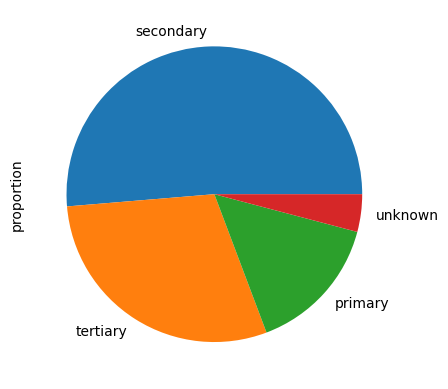

In [75]:
#lets visualise
inp0['edu'].value_counts(normalize=True).plot(kind='pie')

### **Missing Value Identifcation & Treatment**

In [76]:
#Age

inp0.age.isnull().sum()

np.int64(20)

In [77]:
inp0.age.isnull().value_counts(normalize=True)*100

,proportion
age,
False,99.955763
True,0.044237


In [78]:
# 0.04% is the missing value occupancy for Age Column in Dataframe so we are going to delete it

In [79]:
#Excluding Rows Containing NaN in Age Column
inp1 = inp0[~inp0['age'].isna()]

In [81]:
#Lets check
inp1.age.isna().sum()

np.int64(0)

In [82]:
#Month attribute now

inp1.month.isna().sum()

np.int64(50)

In [83]:
#% of missing values
inp1.month.isna().value_counts(normalize=True)*100

,proportion
month,
False,99.889359
True,0.110641


In [84]:
inp1.month.head()

,month
0,"may, 2017"
1,"may, 2017"
2,"may, 2017"
3,"may, 2017"
4,"may, 2017"


In [85]:
#Since its a categorical data we will have to use mode to replacing the null values

inp1.month.mode()[0]

'may, 2017'

In [87]:
#use .fillna() to replace NaN in Month with Mode

inp1.month.fillna(inp1.month.mode()[0], inplace=True)

In [92]:
#Check
inp1.month.isna().sum()

np.int64(0)

In [ ]:
# Pdays Attribute now

# this column represents the days values.
# After how many days the customer was contacted since last campaign.
# -1 indicates Absence of Data .

In [93]:
inp1.pdays.head()

,pdays
0,-1
1,-1
2,-1
3,-1
4,-1


In [94]:
#stats on pdays

inp1.pdays.describe()

,pdays
count,45191.000000
mean,40.181253
std,100.074099
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,871.000000


In [95]:
#replace -1 with Nan so we get proper stats

inp1.loc[inp1.pdays<0,'pdays']= np.nan


In [96]:
#Check

inp1.pdays.describe()

,pdays
count,8252.000000
mean,224.523752
std,115.202715
min,1.000000
25%,133.000000
50%,194.500000
75%,327.000000
max,871.000000


## **Outlier Detection**

Checking extreme values (potential outlier) in Age Column.

In [97]:
inp1.age.describe()

,age
count,45191.000000
mean,40.935651
std,10.619198
min,18.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,95.000000


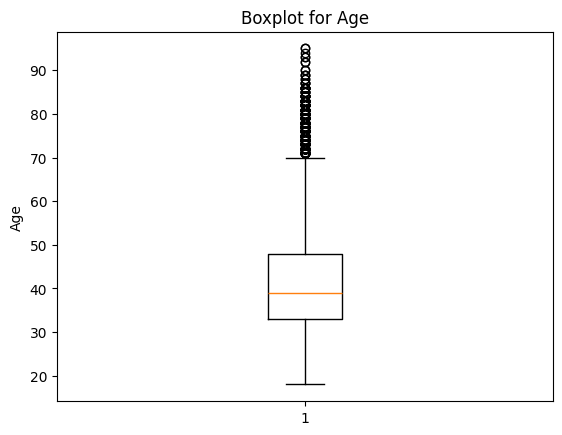

In [98]:
#Lets Visualise
plt.boxplot(inp1.age)
plt.title('Boxplot for Age')
plt.ylabel('Age')
plt.show()

In [99]:
#Not all outliers are needed to be removed so we dont do anything

## **Univariate Analysis**

Analysing Age distribution of Customers using histogram

<Axes: >

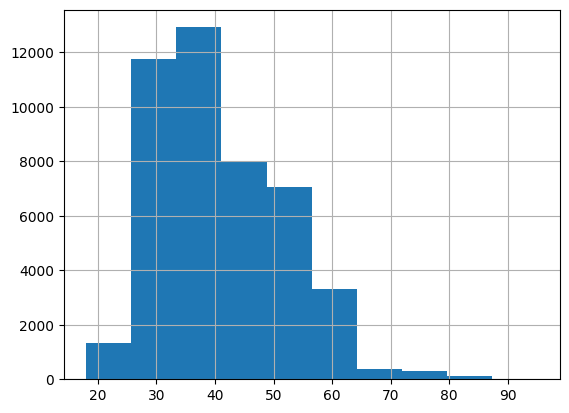

In [101]:
#Lets Visualise

inp1.age.hist()

In [104]:
#Checking no of customers btw 30 n 50

inp1[inp1.age.between(30,50)].shape


(30671, 20)

## **Bi-Varient Analysis**

Customer distribution by their Job, Age




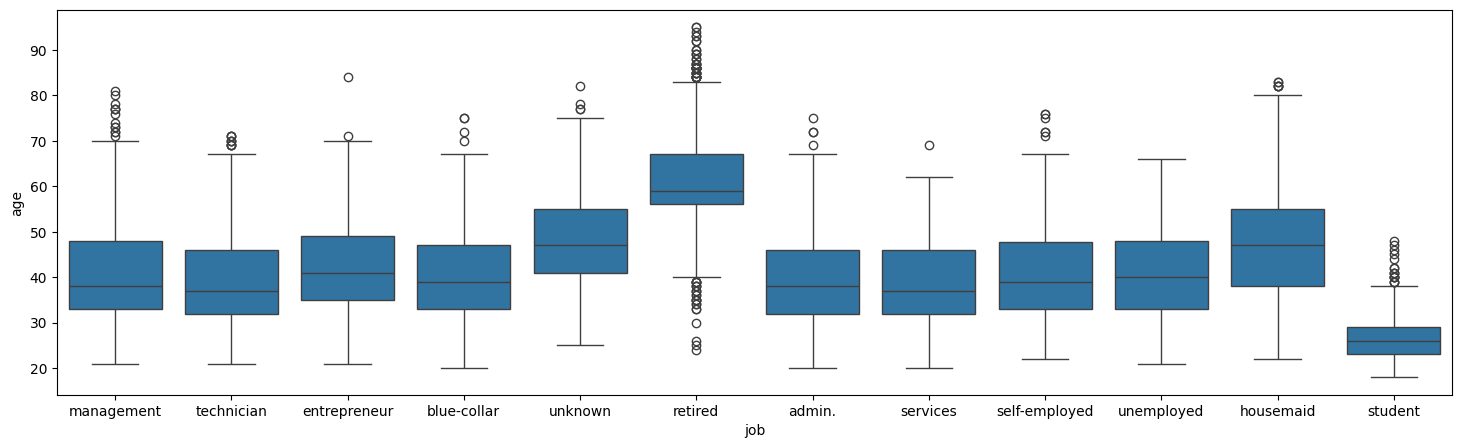

In [110]:
plt.figure(figsize=(18,5))
sns.boxplot( x='job',y='age',data=inp1);

## **Multi-Varient Analysis**

Customer distribution by their Job, Age and Marital Status




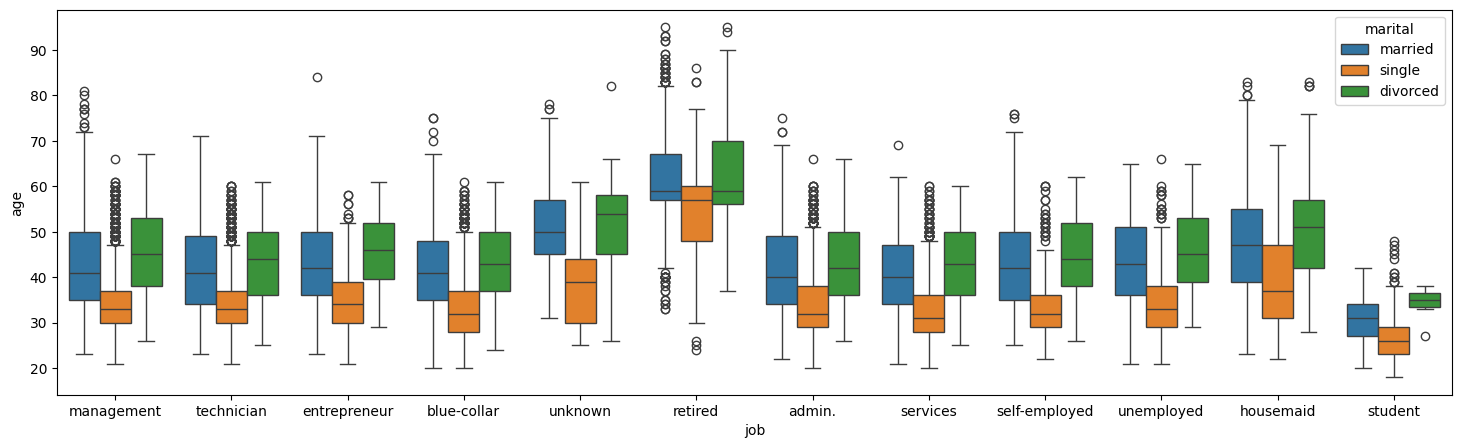

In [111]:
plt.figure(figsize=(18,5))
sns.boxplot( x='job',y=inp1.age,hue='marital',data=inp1);

<Axes: ylabel='marital'>

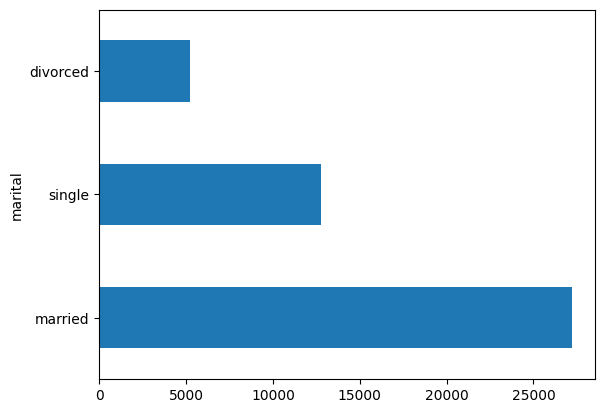

In [116]:
#let us find the customer details by their marital status

inp1.marital.value_counts().plot(kind='barh')

<Axes: ylabel='job'>

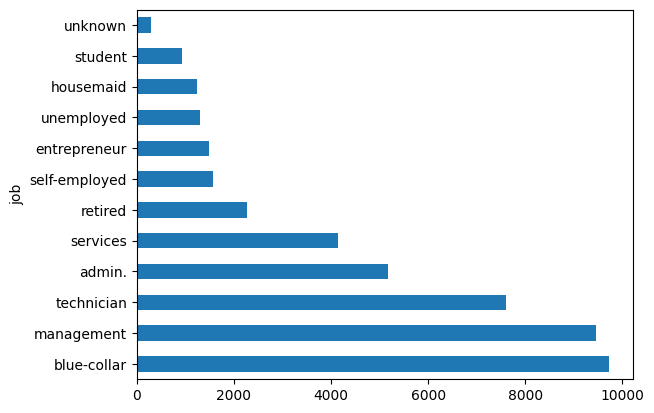

In [115]:
#finding the distibution of customers by their Job
inp1.job.value_counts().plot(kind='barh')

<Axes: ylabel='count'>

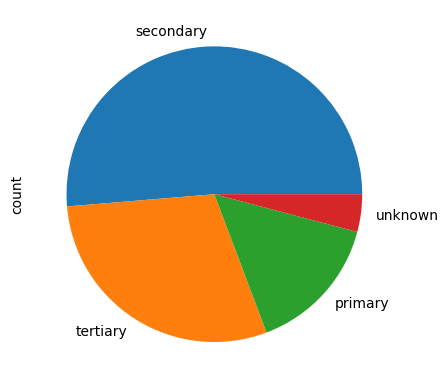

In [118]:
# Finding the Customer Distribution by their Education.

inp1.edu.value_counts().plot(kind='pie')

### **Bivariate Analysis (deep dive)**

Let us analyse the relation between the salary of customer and the balance they have in their Account

For Bivariate Analysis we use Scatter Plot

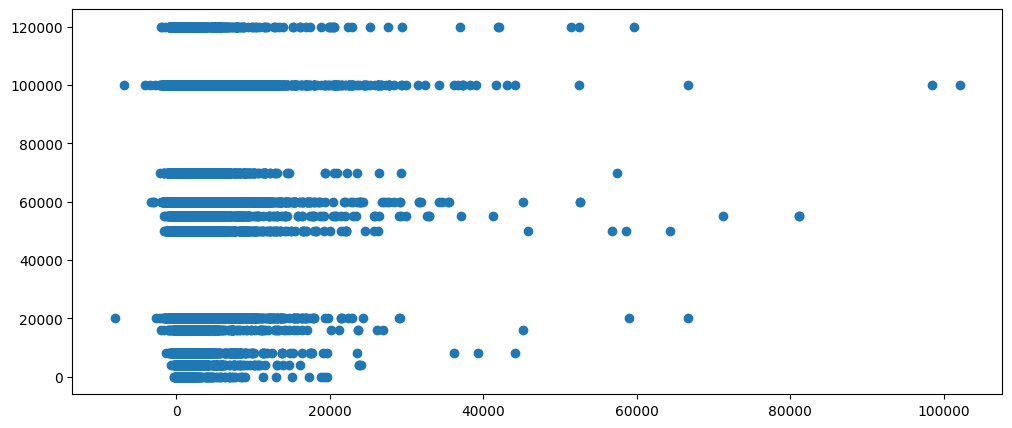

In [119]:
plt.figure(figsize=(12,5))
plt.scatter(inp1.balance,inp1.salary) # x, y axis values
plt.show()

Let us analyse the relation between the Salary and Age

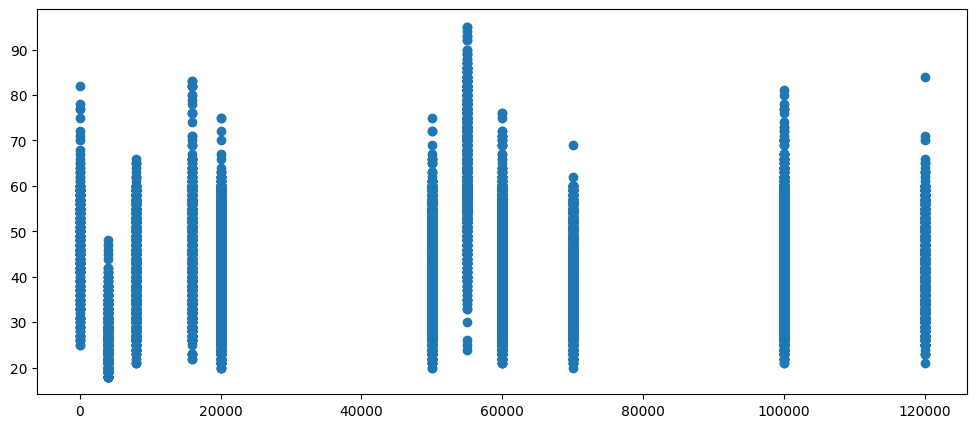

In [123]:
plt.figure(figsize=(12,5))
plt.scatter(inp1.salary,inp1.age) # x, y axis values
plt.show()

Let us analyse the relation between the Age vs Balance

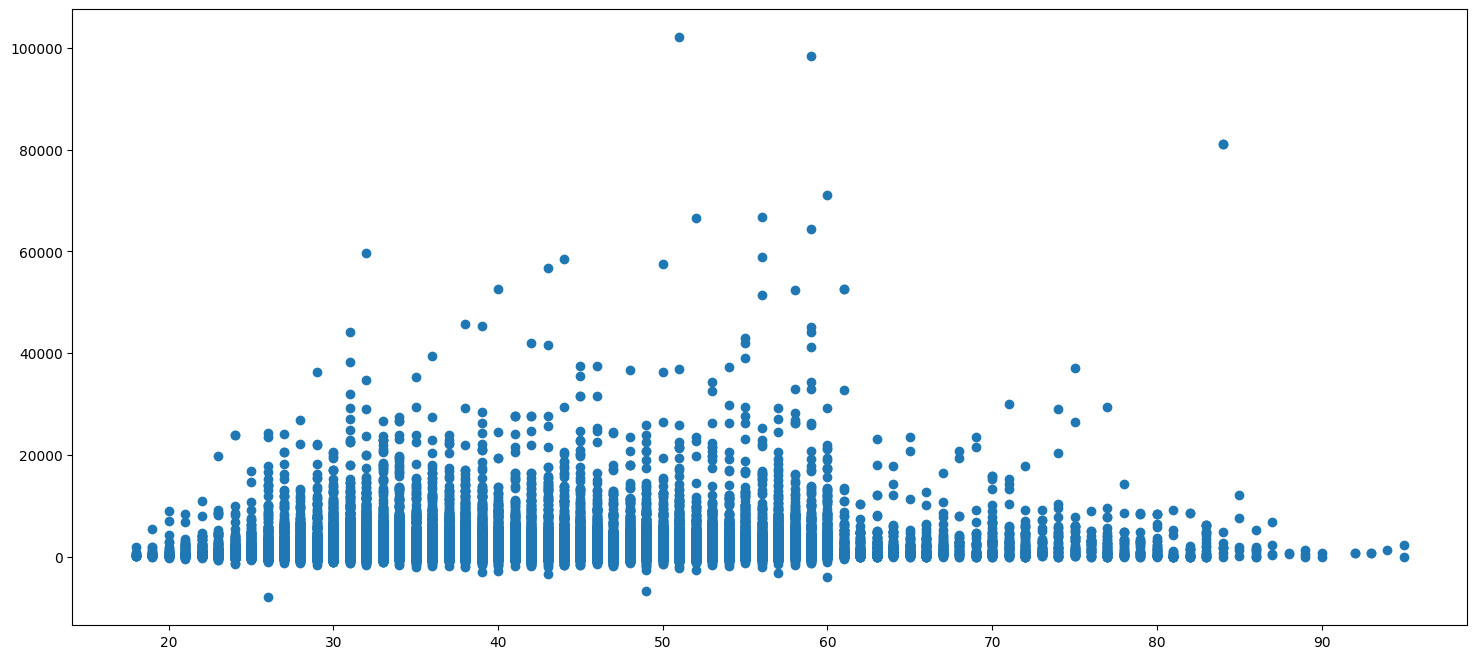

In [126]:
plt.figure(figsize=(18,8))
plt.scatter(inp1.age,inp1.balance) # x, y axis values
plt.show()

### **MulitiVariate Analysis (Deep Dive)**

Let us find the correlation between Age, Salary and Balance.


Correlation tells us how strongly two variables are related to each other. It ranges from -1 to 1



-1 : perfect negative correlation, as one increases the other decreases

0 : no relationship between the two variables

1 : perfect positive correlation, both increase together

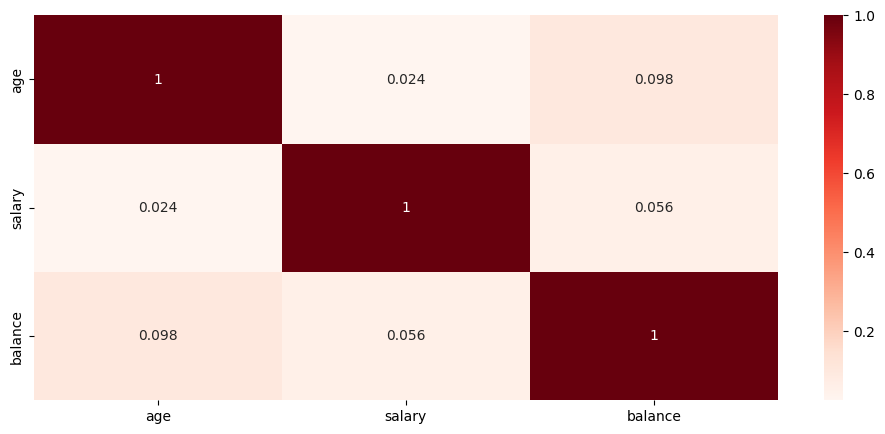

In [127]:
plt.figure(figsize=(12,5))
sns.heatmap(inp1[['age','salary','balance']].corr(),annot=True,cmap="Reds")
plt.show()

# **Key Insights**

Based on the EDA performed on the Bank Telemarketing Campaign data, here are my key findings:

**Customer Profile:**
- Majority of customers fall between the age of 30 to 50 years.
- Most customers are married, followed by single and divorced.
- A large portion of customers have secondary level education.
- Blue-collar, management and technician are the most common job categories.

**Age & Job:**
- Management and admin roles tend to have a wider age range compared to blue-collar jobs.
- When marital status is factored in, married customers dominate across most job categories.

**Salary & Balance:**
- There is no strong corelation between age and salary, or age and balance — meaning age alone doesn't determine how much a customer earns or saves.
- Similarly salary and balance show a weak relationship, suggesting high earners don't necesarily maintain high balances.

**Data Quality:**
- Age had very few missing values (~0.04%) so those rows were dropped.
- Month had missing values which were replaced with the mode.
- pdays had -1 values indicating no prior contact, these were treated as missing values.

# **Next Steps**

The insights from this EDA can be used to target the right customer segments for future telemarketing campaigns by focusing on middle aged customers in management or admin roles could improve campaign conversion rates and reduce marketing costs.